In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
import csv  
from matplotlib.colors import ListedColormap
from cartopy.feature import LAKES
import matplotlib.ticker as mticker

C:\Users\x12la\AppData\Local\Temp\ipykernel_24604\2339906611.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


In [2]:
# Idling data from both EPA and scaled data 
epa_oni = pd.read_csv('ONI_2022v1_projected_from_full_annual_20240226_monthly_18jun2024_nf_v5.csv',skiprows=14)
epa_hotelling = pd.read_csv('HOTELING_2022v1_monthly_20240305_18jun2024_nf_v5.csv',skiprows=19)

locus_oni = pd.read_csv('NewActivityInputs/ONI_2022v1_LOCUS_scaled.csv',skiprows=14)
locus_hotelling = pd.read_csv('NewActivityInputs/HOTELING_2022v1_LOCUS_scaled.csv',skiprows=19)

cols = [
    "country_cd", "region_cd", "tribal_code", "census_tract_cd", "shape_id", "scc",
    "act_parm_type_cd", "act_parm_uofmsr", "activity_type", "ann_parm_value",
    "calc_year", "date_updated", "data_set_id",
    "jan_value", "feb_value", "mar_value", "apr_value", "may_value", "jun_value",
    "jul_value", "aug_value", "sep_value", "oct_value", "nov_value", "dec_value",
    "comment"
]

# Assign headers 
epa_oni.columns = cols
epa_hotelling.columns = cols
locus_oni.columns = cols
locus_hotelling.columns = cols

In [3]:
epa_hotelling.loc[epa_hotelling['region_cd']==17031]

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value,comment
469,US,17031,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,3500373.36,...,301792.561570,304324.637150,305054.380990,293501.790750,310373.191310,287663.945070,315807.163910,289862.179540,258904.429500,NaN
470,US,17031,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,380306.64,...,32788.992277,33064.095832,33143.380639,31888.221168,33721.255818,31253.954121,34311.643086,31492.786691,28129.306087,NaN


In [4]:
locus_hotelling.loc[locus_hotelling['region_cd']==17031]

,country_cd,region_cd,tribal_code,census_tract_cd,shape_id,scc,act_parm_type_cd,act_parm_uofmsr,activity_type,ann_parm_value,...,apr_value,may_value,jun_value,jul_value,aug_value,sep_value,oct_value,nov_value,dec_value,comment
468,US,17031,NaN,NaN,NaN,2202620153,NaN,NaN,HOTELLING,1.215189e+07,...,1.047703e+06,1.056493e+06,1.059026e+06,1.018920e+06,1.077491e+06,998653.625442,1.096356e+06,1.006285e+06,898812.131687,NaN
469,US,17031,NaN,NaN,NaN,2202620191,NaN,NaN,HOTELLING,1.320272e+06,...,1.138302e+05,1.147853e+05,1.150605e+05,1.107031e+05,1.170667e+05,108501.169949,1.191162e+05,1.093303e+05,97653.646235,NaN


In [5]:
def prep(df):
    df = df.copy()
    df["region_cd"] = df["region_cd"].astype(str).str.zfill(5)
    scc = df["scc"].astype(str).str.zfill(10)
    df["veh_code"]  = scc.str[4:6]       
    df["proc_code"] = scc.str[8:10]     
    df["ann_parm_value"] = pd.to_numeric(df["ann_parm_value"], errors="coerce").fillna(0.0)
    return df

epa_oni_p        = prep(epa_oni)
epa_hotelling_p  = prep(epa_hotelling)
locus_oni_p      = prep(locus_oni)
locus_hotelling_p= prep(locus_hotelling)

MDV_CODES = {"52","53"}  #MDVs -- single unit trucks
HDV_CODES = {"61","62"}  #HDVS - combiniation trucks
HOT_EXT   = "53"   # Extended Idle
HOT_APU   = "91"   # Auxiliary Power Unit

In [6]:
#CMAP Counties 
target_names = {
    "17031": "Cook",
    "17043": "DuPage",
    "17089": "Kane",
    "17093": "Kendall",
    "17097": "Lake",
    "17111": "McHenry",
    "17197": "Will",
}
target_fips = list(target_names.keys())

In [7]:
def aggregate_by_county(oni_df, hot_df):
    # MDV ONI
    mdv_oni = (
        oni_df[oni_df["veh_code"].isin(MDV_CODES)]
        .groupby("region_cd")["ann_parm_value"].sum()
        .reindex(target_fips, fill_value=0.0)
        .rename("MDV_ONI_ann")
    )
    # HDV ONI
    hdv_oni = (
        oni_df[oni_df["veh_code"].isin(HDV_CODES)]
        .groupby("region_cd")["ann_parm_value"].sum()
        .reindex(target_fips, fill_value=0.0)
        .rename("HDV_ONI_ann")
    )
    # HDV Hotelling split
    hot = hot_df[hot_df["veh_code"].isin(HDV_CODES)].copy()
    hot_ext = (
        hot[hot["proc_code"] == HOT_EXT]
        .groupby("region_cd")["ann_parm_value"].sum()
        .reindex(target_fips, fill_value=0.0)
        .rename("HDV_HOT_EXT_ann")
    )
    hot_apu = (
        hot[hot["proc_code"] == HOT_APU]
        .groupby("region_cd")["ann_parm_value"].sum()
        .reindex(target_fips, fill_value=0.0)
        .rename("HDV_HOT_APU_ann")
    )
    hot_total = (hot_ext + hot_apu).rename("HDV_HOT_Total_ann")
    hdv_total = (hdv_oni + hot_total).rename("HDV_Total_ann")
    out = pd.concat([mdv_oni, hdv_oni, hot_ext, hot_apu, hot_total, hdv_total], axis=1)
    out.insert(0, "County", [target_names[f] for f in out.index])
    return out

epa_tbl   = aggregate_by_county(epa_oni_p,   epa_hotelling_p)
locus_tbl = aggregate_by_county(locus_oni_p, locus_hotelling_p)

def add_total_row(df, label="CMAP Total"):
    total = df.select_dtypes(include="number").sum()
    total["County"] = label
    return pd.concat([df, total.to_frame().T])

In [18]:
epa_tbl_tot   = add_total_row(epa_tbl)
locus_tbl_tot = add_total_row(locus_tbl)

pd.set_option("display.float_format", "{:,.0f}".format)

print("\n=== EPA Annual Idling Hours (hours/year) ===\n")
print(epa_tbl_tot.to_string())

print("\n=== LOCUS Annual Idling Hours (hours/year) ===\n")
print(locus_tbl_tot.to_string())


=== EPA Annual Idling Hours (hours/year) ===

           County MDV_ONI_ann HDV_ONI_ann HDV_HOT_EXT_ann HDV_HOT_APU_ann HDV_HOT_Total_ann HDV_Total_ann
17031        Cook  14,998,141   8,237,801       3,500,373         380,307         3,880,680    12,118,481
17043      DuPage   3,464,744   2,020,107       1,741,196         189,177         1,930,373     3,950,480
17089        Kane   1,813,356     997,016         845,534          91,865           937,399     1,934,414
17093     Kendall     400,530     138,240               0               0                 0       138,240
17097        Lake   2,556,311   1,261,352         793,176          86,176           879,352     2,140,704
17111     McHenry   1,096,429     546,579          94,818          10,302           105,120       651,699
17197        Will   2,596,116   1,518,685       1,343,052         145,919         1,488,971     3,007,656
0      CMAP Total  26,925,627  14,719,779       8,318,149         903,746         9,221,894    23,941,674

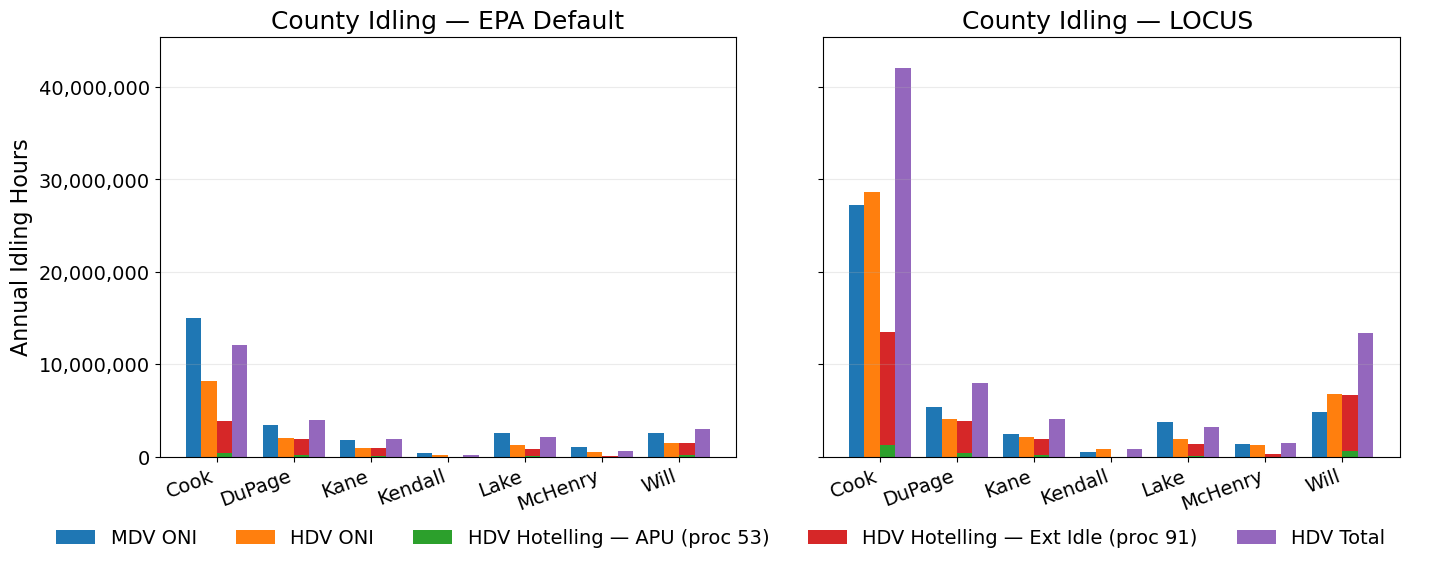

In [14]:
counties = [target_names[f] for f in target_fips]
x = np.arange(len(counties))
w = 0.2  # bar width

def draw_panel(ax, tbl, title):
    # Bars: MDV ONI, HDV ONI, Hotelling (stacked APU + Ext Idle), HDV Total
    ax.bar(x - 1.5*w, tbl["MDV_ONI_ann"].values, width=w, label="MDV ONI")
    ax.bar(x - 0.5*w, tbl["HDV_ONI_ann"].values, width=w, label="HDV ONI")

    hot_apu_vals = tbl["HDV_HOT_APU_ann"].values
    hot_ext_vals = tbl["HDV_HOT_EXT_ann"].values
    ax.bar(x + 0.5*w, hot_apu_vals, width=w, label="HDV Hotelling — APU (proc 53)")
    ax.bar(x + 0.5*w, hot_ext_vals, width=w, bottom=hot_apu_vals, label="HDV Hotelling — Ext Idle (proc 91)")

    ax.bar(x + 1.5*w, tbl["HDV_Total_ann"].values, width=w, label="HDV Total")
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(counties, rotation=20, ha="right",fontsize=14)
    ax.set_title(title,fontsize=18)
    ax.grid(axis="y", alpha=0.25)

# Common ymax
def get_ymax(tbl):
    cols = ["MDV_ONI_ann","HDV_ONI_ann","HDV_HOT_APU_ann","HDV_HOT_EXT_ann","HDV_Total_ann"]
    return float(tbl[cols].to_numpy().max())

ymax = max(get_ymax(epa_tbl), get_ymax(locus_tbl)) * 1.08  # headroom

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

draw_panel(ax1, epa_tbl,   "County Idling — EPA Default")
draw_panel(ax2, locus_tbl, "County Idling — LOCUS ")

ax1.set_ylabel("Annual Idling Hours",fontsize=16)
ax1.set_ylim(0, ymax)

ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=14)
plt.subplots_adjust(bottom=0.18, wspace=0.15)

plt.show()

<h1> Print idling totals for IL

In [8]:
def summarize_il(oni_df, hot_df):
    """Return IL totals for MDV/HDV ONI and HDV hotelling (hours/year)."""
    # Illinois = state FIPS 17 -> region_cd starts with "17"
    oni_il = oni_df[oni_df["region_cd"].str.startswith("17")].copy()
    hot_il = hot_df[hot_df["region_cd"].str.startswith("17")].copy()

    # ONI: MDV and HDV
    mdv_oni = oni_il[oni_il["veh_code"].isin(MDV_CODES)]["ann_parm_value"].sum()
    hdv_oni = oni_il[oni_il["veh_code"].isin(HDV_CODES)]["ann_parm_value"].sum()

    # Hotelling: HDV only, split by process (aux, exhaust)
    hot_hdv = hot_il[hot_il["veh_code"].isin(HDV_CODES)].copy()

    hot_ext = hot_hdv[hot_hdv["proc_code"] == HOT_EXT]["ann_parm_value"].sum()
    hot_apu = hot_hdv[hot_hdv["proc_code"] == HOT_APU]["ann_parm_value"].sum()
    hot_total = hot_ext + hot_apu

    return mdv_oni, hdv_oni, hot_ext, hot_apu, hot_total

def print_il_summary(label, oni_df, hot_df):
    mdv_oni, hdv_oni, hot_ext, hot_apu, hot_total = summarize_il(oni_df, hot_df)
    print(f"\n=== Illinois Idling Hours — {label} ===")
    print(f"MDV ONI:          {mdv_oni:,.0f} hours/year")
    print(f"HDV ONI:          {hdv_oni:,.0f} hours/year")
    print(f"HDV Hotelling EXT ({HOT_EXT}): {hot_ext:,.0f} hours/year")
    print(f"HDV Hotelling APU ({HOT_APU}): {hot_apu:,.0f} hours/year")
    print(f"HDV Hotelling TOTAL: {hot_total:,.0f} hours/year")


print_il_summary("EPA",   epa_oni_p,   epa_hotelling_p)
print_il_summary("LOCUS", locus_oni_p, locus_hotelling_p)


=== Illinois Idling Hours — EPA ===
MDV ONI:          47,462,606 hours/year
HDV ONI:          32,793,225 hours/year
HDV Hotelling EXT (53): 25,700,930 hours/year
HDV Hotelling APU (91): 2,792,341 hours/year
HDV Hotelling TOTAL: 28,493,270 hours/year

=== Illinois Idling Hours — LOCUS ===
MDV ONI:          76,652,841 hours/year
HDV ONI:          69,539,179 hours/year
HDV Hotelling EXT (53): 45,154,373 hours/year
HDV Hotelling APU (91): 4,905,908 hours/year
HDV Hotelling TOTAL: 50,060,281 hours/year


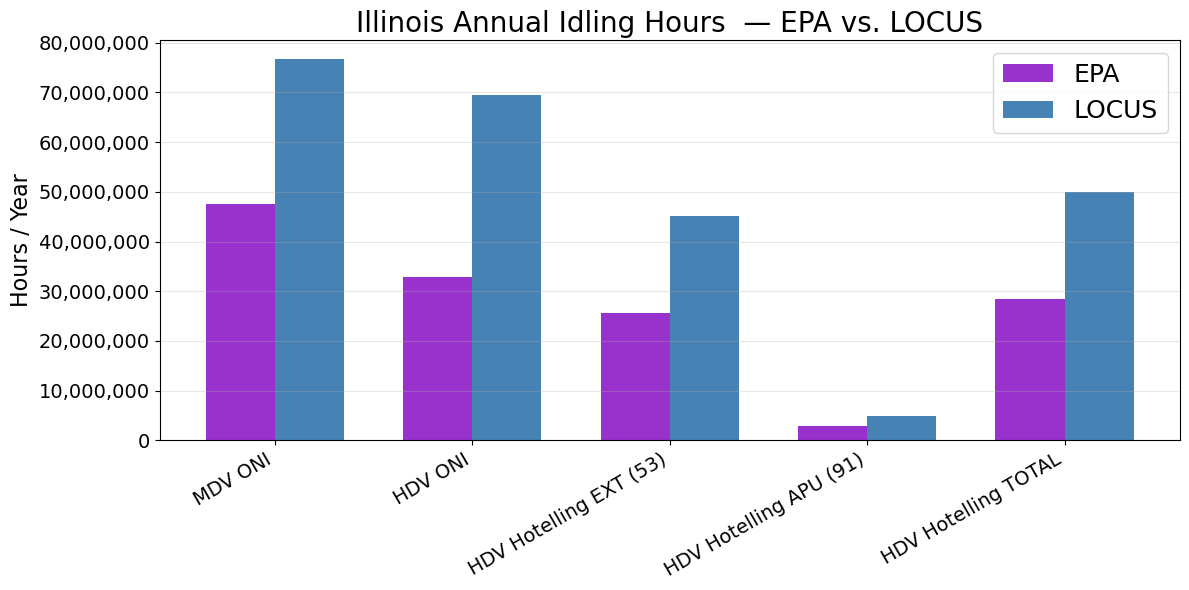

In [9]:
epa_vals   = summarize_il(epa_oni_p,   epa_hotelling_p)
locus_vals = summarize_il(locus_oni_p, locus_hotelling_p)

epa_vals   = np.array(epa_vals)
locus_vals = np.array(locus_vals)

categories = [
    "MDV ONI",
    "HDV ONI",
    "HDV Hotelling EXT (53)",
    "HDV Hotelling APU (91)",
    "HDV Hotelling TOTAL"
]

x = np.arange(len(categories))
w = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - w/2, epa_vals,   width=w, label="EPA",   color="darkorchid")
ax.bar(x + w/2, locus_vals, width=w, label="LOCUS", color="steelblue")

ax.set_xticks(x)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(categories, rotation=30, ha="right",fontsize=14)
ax.set_ylabel("Hours / Year",fontsize=16)
ax.set_title("Illinois Annual Idling Hours  — EPA vs. LOCUS",fontsize=20)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=18)

# nice formatting
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

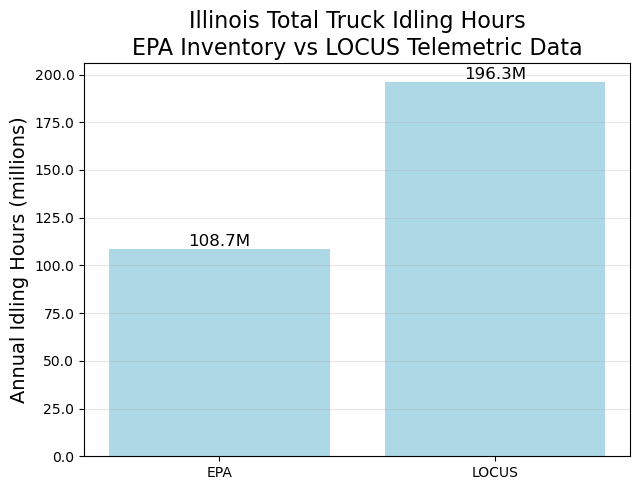

In [20]:
labels = ["EPA", "LOCUS"]
vals = [epa_grand, loc_grand]

fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(labels, vals, color='lightblue')

ax.set_ylabel("Annual Idling Hours (millions)", fontsize=14)
ax.set_title(
    "Illinois Total Truck Idling Hours\nEPA Inventory vs LOCUS Telemetric Data",
    fontsize=16
)
ax.grid(axis="y", alpha=0.3)

# ---- format y-axis in millions ----
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}")
)

# ---- annotate bars in millions ----
for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        h,
        f"{h/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()
plt.show()


In [21]:
# ---- percent increase LOCUS vs EPA ----
pct_increase = (loc_grand - epa_grand) / epa_grand * 100

print("\n=== LOCUS vs EPA: Total Idling Difference ===")
print(f"Absolute increase: {(loc_grand - epa_grand)/1e6:,.1f} million hours/year")
print(f"Percent increase: {pct_increase:,.1f}%")



=== LOCUS vs EPA: Total Idling Difference ===
Absolute increase: 87.5 million hours/year
Percent increase: 80.5%
